In [59]:
#@title Imports & Utils

import pandas as pd
import ast
from sklearn.metrics import confusion_matrix
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter
from sklearn import metrics

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn import metrics
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

In [2]:
distmult_test_preds = pd.read_csv("/content/distmult-test-preds.tsv", index_col=False, sep="\t").dropna().drop_duplicates().reset_index(drop=True)
distmult_val_preds = pd.read_csv("/content/distmult-val-preds.tsv", index_col=False, sep="\t").dropna().drop_duplicates().reset_index(drop=True)

roberta_test_preds = pd.read_csv("/content/roberta-test-preds.tsv", index_col=False, sep="\t").applymap(lambda x: x.strip()).dropna().drop_duplicates().reset_index(drop=True)
roberta_val_preds = pd.read_csv("/content/roberta-val-preds.tsv", index_col=False, sep="\t").applymap(lambda x: x.strip()).dropna().drop_duplicates().reset_index(drop=True)

In [3]:
assert len(distmult_test_preds) == len(roberta_test_preds)
assert len(distmult_val_preds) == len(roberta_val_preds)

# **Data Exploration**

In [140]:
dictionary = {label: idx for idx, label in enumerate(set(distmult_test_preds['true'].values.tolist()))}
labels = list(dictionary.keys())
dictionary

{'noRel': 0, 'Attack': 1, 'Support': 2}

In [5]:
distmult_test_preds.head()

,true,predicted,sentence1,sentence2
0,Support,Support,I did serve in combat,"I was shot down when I was a young kid, scared..."
1,Support,Support,we want to do is commit more forces anywhere,"What I want the President to do, and I think h..."
2,Support,noRel,We need to call upon Syria to release the thre...,The first priority has to be on ending the vio...
3,Attack,noRel,that's not the way this country ought to be run,"Mr. Ford, so far as I know, except for avoidin..."
4,Attack,Support,if we remain dependent on a source of energy t...,No matter how strong we are economically


In [6]:
roberta_test_preds.head()

,true,predicted,sentence1,sentence2
0,Support,Support,I did serve in combat,"I was shot down when I was a young kid, scared..."
1,Support,Support,we want to do is commit more forces anywhere,"What I want the President to do, and I think h..."
2,Support,Support,We need to call upon Syria to release the thre...,The first priority has to be on ending the vio...
3,Attack,noRel,that's not the way this country ought to be run,"Mr. Ford, so far as I know, except for avoidin..."
4,Attack,Support,if we remain dependent on a source of energy t...,No matter how strong we are economically


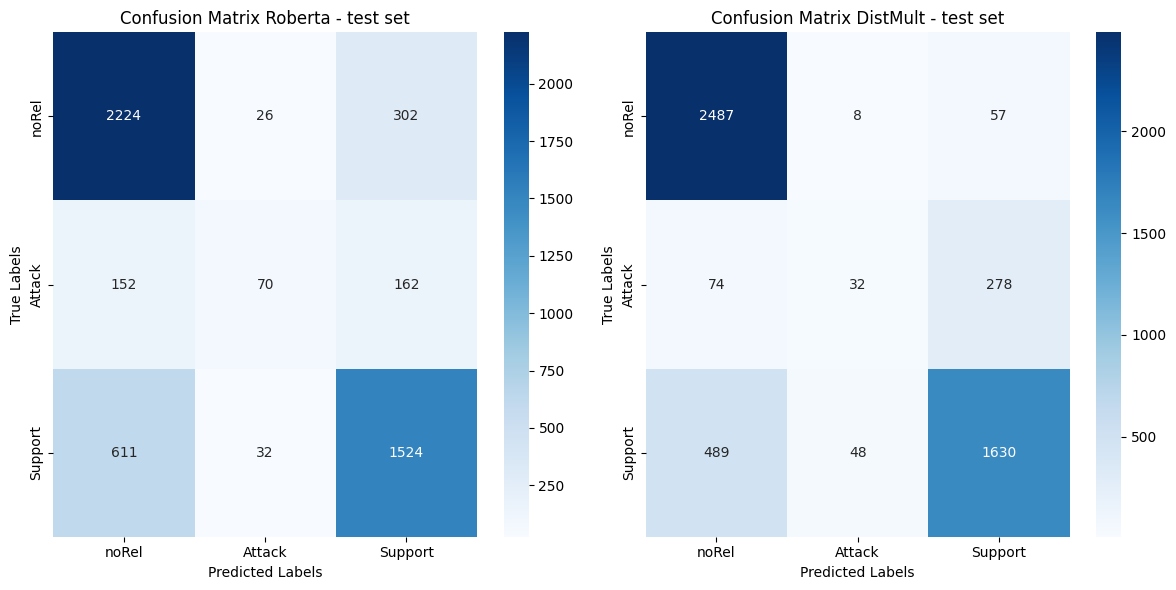

In [8]:
# Plotting Confusion Matrix for Roberta - test dataset
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
sns.heatmap(confusion_matrix(roberta_test_preds['true'].map(lambda x: dictionary.get(x)), \
                             roberta_test_preds['predicted'].map(lambda x: dictionary.get(x))), \
            annot=True, cmap='Blues', xticklabels=labels, yticklabels=labels, fmt='g')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix Roberta - test set')

# Plotting Confusion Matrix for DistMult - test dataset
plt.subplot(1, 2, 2)
sns.heatmap(confusion_matrix(distmult_test_preds['true'].map(lambda x: dictionary.get(x)), \
                             distmult_test_preds['predicted'].map(lambda x: dictionary.get(x))), \
            annot=True, cmap='Blues', xticklabels=labels, yticklabels=labels, fmt='g')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix DistMult - test set')

plt.tight_layout()
plt.show()

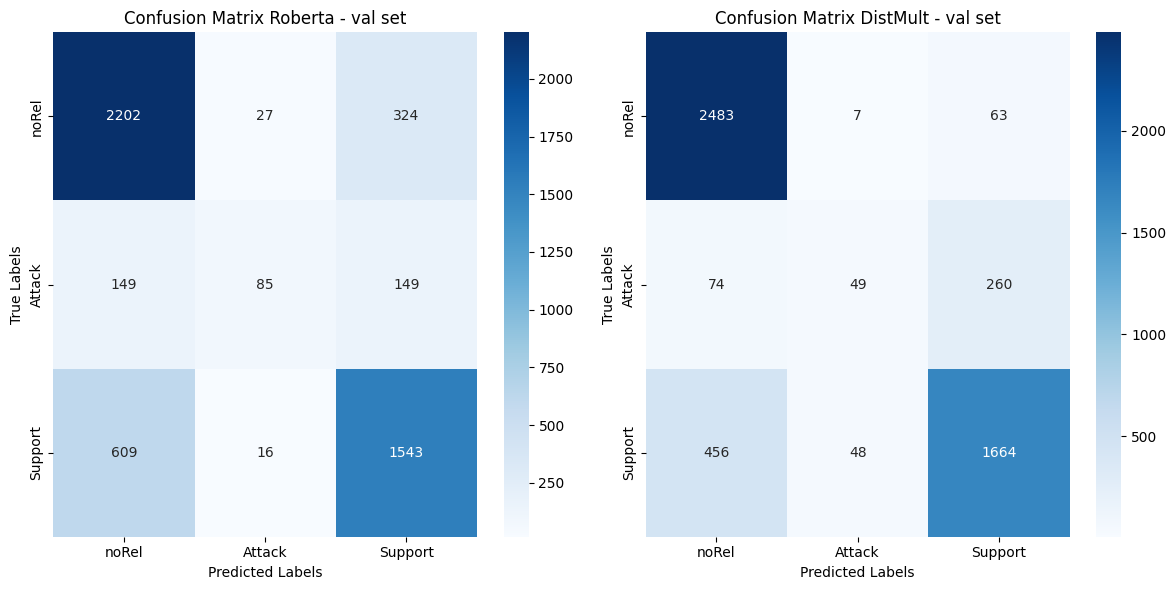

In [9]:
# Plotting Confusion Matrix for Roberta - val dataset
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
sns.heatmap(confusion_matrix(roberta_val_preds['true'].map(lambda x: dictionary.get(x)), \
                             roberta_val_preds['predicted'].map(lambda x: dictionary.get(x))), \
            annot=True, cmap='Blues', xticklabels=labels, yticklabels=labels, fmt='g')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix Roberta - val set')

# Plotting Confusion Matrix for DistMult - val dataset
plt.subplot(1, 2, 2)
sns.heatmap(confusion_matrix(distmult_val_preds['true'].map(lambda x: dictionary.get(x)), \
                             distmult_val_preds['predicted'].map(lambda x: dictionary.get(x))), \
            annot=True, cmap='Blues', xticklabels=labels, yticklabels=labels, fmt='g')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix DistMult - val set')

plt.tight_layout()
plt.show()

In [14]:
print("Roberta evaluation on test set: \n")
true = roberta_test_preds['true']
preds = roberta_test_preds['predicted']
print(f"F1-macro: {metrics.f1_score(true, preds, average='macro')}")
print(f"F1-micro: {metrics.f1_score(true, preds, average='micro')}")
print(f"Accuracy: {metrics.accuracy_score(true, preds)}")
print(f"Recall: {metrics.recall_score(true, preds, average='macro')}")
print(f"Precision: {metrics.precision_score(true, preds, average='macro')}")

Roberta evaluation on test set: 

F1-macro: 0.6033481818916039
F1-micro: 0.7481873407799333
Accuracy: 0.7481873407799333
Recall: 0.5856804799703671
Precision: 0.686011452180329


In [16]:
print("Roberta evaluation on val set: \n")
true = roberta_val_preds['true']
preds = roberta_val_preds['predicted']
print(f"F1-macro: {metrics.f1_score(true, preds, average='macro')}")
print(f"F1-micro: {metrics.f1_score(true, preds, average='micro')}")
print(f"Accuracy: {metrics.accuracy_score(true, preds)}")
print(f"Recall: {metrics.recall_score(true, preds, average='macro')}")
print(f"Precision: {metrics.precision_score(true, preds, average='macro')}")

Roberta evaluation on val set: 

F1-macro: 0.6230306089657685
F1-micro: 0.7503918495297806
Accuracy: 0.7503918495297806
Recall: 0.5987208902142744
Precision: 0.7244528010153011


In [15]:
print("DistMult evaluation on test set: \n")
true = distmult_test_preds['true']
preds = distmult_test_preds['predicted']
print(f"F1-macro: {metrics.f1_score(true, preds, average='macro')}")
print(f"F1-micro: {metrics.f1_score(true, preds, average='micro')}")
print(f"Accuracy: {metrics.accuracy_score(true, preds)}")
print(f"Recall: {metrics.recall_score(true, preds, average='macro')}")
print(f"Precision: {metrics.precision_score(true, preds, average='macro')}")

DistMult evaluation on test set: 

F1-macro: 0.6041515273039656
F1-micro: 0.8130511463844796
Accuracy: 0.8130511463844797
Recall: 0.603351694787893
Precision: 0.6695209130473804


In [17]:
print("DistMult evaluation on val set: \n")
true = distmult_val_preds['true']
preds = distmult_val_preds['predicted']
print(f"F1-macro: {metrics.f1_score(true, preds, average='macro')}")
print(f"F1-micro: {metrics.f1_score(true, preds, average='micro')}")
print(f"Accuracy: {metrics.accuracy_score(true, preds)}")
print(f"Recall: {metrics.recall_score(true, preds, average='macro')}")
print(f"Precision: {metrics.precision_score(true, preds, average='macro')}")

DistMult evaluation on val set: 

F1-macro: 0.6314657958009401
F1-micro: 0.822100313479624
Accuracy: 0.8221003134796239
Recall: 0.622682096340159
Precision: 0.7108976046438746


# **In-Pipeline evaluation**
Simulating what will happen if models are stacked in a pipeline:



### 1.
Distmults predics which nodes don't have any relation and Roberta (trained with multi-class classification) predics the rest

In [18]:
no_rel_distmult = distmult_test_preds[distmult_test_preds['predicted'] == 'noRel']
len(no_rel_distmult)

3050

In [19]:
combined_dataset = pd.DataFrame({'y_true': distmult_test_preds['true'].values.tolist(), \
                                 'distmult_pred': distmult_test_preds['predicted'].values.tolist(), \
                                 'roberta_pred': roberta_test_preds['predicted'].values.tolist()})

In [20]:
combined_dataset['y_pred'] = np.where(combined_dataset['distmult_pred'] == 'noRel',
                                          combined_dataset['distmult_pred'],
                                          combined_dataset['roberta_pred'])
combined_dataset.head()

,y_true,distmult_pred,roberta_pred,y_pred
0,Support,Support,Support,Support
1,Support,Support,Support,Support
2,Support,noRel,Support,noRel
3,Attack,noRel,noRel,noRel
4,Attack,Support,Support,Support


In [22]:
print("DistMult f1-score")
print(metrics.f1_score(distmult_test_preds['true'], distmult_test_preds['predicted'], average='macro'))

print("Roberta f1-score")
print(metrics.f1_score(roberta_test_preds['true'], roberta_test_preds['predicted'], average='macro'))

print("Combined f1-score")
print(metrics.f1_score(combined_dataset['y_true'], combined_dataset['y_pred'], average='macro'))

DistMult f1-score
0.6041515273039656
Roberta f1-score
0.6033481818916039
Combined f1-score
0.5752762820652325


### 2.

Roberta predics which nodes don't have any relation and DistMult (trained with multi-class classification) predics the rest

In [23]:
combined_dataset = pd.DataFrame({'y_true': distmult_test_preds['true'].values.tolist(), \
                                 'distmult_pred': distmult_test_preds['predicted'].values.tolist(), \
                                 'roberta_pred': roberta_test_preds['predicted'].values.tolist()})
combined_dataset['y_pred'] = np.where(combined_dataset['roberta_pred'] == 'noRel',
                                          combined_dataset['roberta_pred'],
                                          combined_dataset['distmult_pred'])
combined_dataset.head()

,y_true,distmult_pred,roberta_pred,y_pred
0,Support,Support,Support,Support
1,Support,Support,Support,Support
2,Support,noRel,Support,noRel
3,Attack,noRel,noRel,noRel
4,Attack,Support,Support,Support


In [24]:
print("DistMult f1-score")
print(metrics.f1_score(distmult_test_preds['true'], distmult_test_preds['predicted'], average='macro'))

print("Roberta f1-score")
print(metrics.f1_score(roberta_test_preds['true'], roberta_test_preds['predicted'], average='macro'))

print("Combined f1-score")
print(metrics.f1_score(combined_dataset['y_true'], combined_dataset['y_pred'], average='macro'))

DistMult f1-score
0.6041515273039656
Roberta f1-score
0.6033481818916039
Combined f1-score
0.5143628147748487


# **Meta-Classifier**

### Using only predictions from the two models

In [160]:
combined_roberta_preds = pd.concat([roberta_test_preds, roberta_val_preds], axis=0)\
                          .dropna().drop_duplicates().reset_index(drop=True)
print(len(combined_roberta_preds))

10205


In [161]:
combined_distmult_preds = pd.concat([distmult_test_preds, distmult_val_preds], axis=0)\
                            .dropna().drop_duplicates().reset_index(drop=True)
print(len(combined_distmult_preds))

10205


In [162]:
combined_dataset_meta_learner = pd.DataFrame({
    'true': combined_distmult_preds['true'].map(lambda x: dictionary.get(x)),
    'distmult_preds': combined_distmult_preds['predicted'].map(lambda x: dictionary.get(x)),
    'roberta_preds': combined_roberta_preds['predicted'].map(lambda x: dictionary.get(x))
})
true = combined_dataset_meta_learner.pop('true')

In [163]:
combined_dataset_meta_learner.dropna().drop_duplicates().reset_index(drop=True)
combined_dataset_meta_learner.head(5)

,distmult_preds,roberta_preds
0,2,2
1,2,2
2,0,2
3,0,0
4,2,2


#### Decision Trees & Random Forests

In [164]:
X_train, X_test, y_train, y_test = train_test_split(combined_dataset_meta_learner, true, test_size=0.2, random_state=42)

In [165]:
dtc = DecisionTreeClassifier(random_state=0).fit(X_train, y_train)
y_pred = dtc.predict(X_test)

print(f"F1-macro: {metrics.f1_score(y_test, y_pred, average='macro')}")
print(f"F1-micro: {metrics.f1_score(y_test, y_pred, average='micro')}")
print(f"Accuracy: {metrics.accuracy_score(y_test, y_pred)}")
print(f"Recall: {metrics.recall_score(y_test, y_pred, average='macro')}")
print(f"Precision: {metrics.precision_score(y_test, y_pred, average='macro')}")

F1-macro: 0.6858686901472045
F1-micro: 0.8334149926506614
Accuracy: 0.8334149926506614
Recall: 0.666801878163036
Precision: 0.8023727658519965


In [166]:
clf = RandomForestClassifier(max_depth=12, random_state=42).fit(X_train, y_train)
y_pred = clf.predict(X_test)

print(f"F1-macro: {metrics.f1_score(y_test, y_pred, average='macro')}")
print(f"F1-micro: {metrics.f1_score(y_test, y_pred, average='micro')}")
print(f"Accuracy: {metrics.accuracy_score(y_test, y_pred)}")
print(f"Recall: {metrics.recall_score(y_test, y_pred, average='macro')}")
print(f"Precision: {metrics.precision_score(y_test, y_pred, average='macro')}")

F1-macro: 0.6858686901472045
F1-micro: 0.8334149926506614
Accuracy: 0.8334149926506614
Recall: 0.666801878163036
Precision: 0.8023727658519965


#### Support Vector Classifiers

In [167]:
svc_classifier = SVC(kernel='rbf', gamma='scale', random_state=42, class_weight='balanced').fit(X_train, y_train)
y_pred = svc_classifier.predict(X_test)

print(f"F1-macro: {metrics.f1_score(y_test, y_pred, average='macro')}")
print(f"F1-micro: {metrics.f1_score(y_test, y_pred, average='micro')}")
print(f"Accuracy: {metrics.accuracy_score(y_test, y_pred)}")
print(f"Recall: {metrics.recall_score(y_test, y_pred, average='macro')}")
print(f"Precision: {metrics.precision_score(y_test, y_pred, average='macro')}")

F1-macro: 0.6599979911637035
F1-micro: 0.7535521803037727
Accuracy: 0.7535521803037727
Recall: 0.7006142271846302
Precision: 0.656956798946814


#### Ada Boost Classifier

In [168]:
clf = AdaBoostClassifier(n_estimators=100, random_state=42).fit(X_train, y_train)
y_pred = clf.predict(X_test)

print(f"F1-macro: {metrics.f1_score(y_test, y_pred, average='macro')}")
print(f"F1-micro: {metrics.f1_score(y_test, y_pred, average='micro')}")
print(f"Accuracy: {metrics.accuracy_score(y_test, y_pred)}")
print(f"Recall: {metrics.recall_score(y_test, y_pred, average='macro')}")
print(f"Precision: {metrics.precision_score(y_test, y_pred, average='macro')}")

F1-macro: 0.6858686901472045
F1-micro: 0.8334149926506614
Accuracy: 0.8334149926506614
Recall: 0.666801878163036
Precision: 0.8023727658519965


#### Gaussian Naive Bayes

In [169]:
gnb = GaussianNB().fit(X_train, y_train)
y_pred = gnb.predict(X_test)

print(f"F1-macro: {metrics.f1_score(y_test, y_pred, average='macro')}")
print(f"F1-micro: {metrics.f1_score(y_test, y_pred, average='micro')}")
print(f"Accuracy: {metrics.accuracy_score(y_test, y_pred)}")
print(f"Recall: {metrics.recall_score(y_test, y_pred, average='macro')}")
print(f"Precision: {metrics.precision_score(y_test, y_pred, average='macro', zero_division=0)}")

F1-macro: 0.5709383665221733
F1-micro: 0.8201861832435081
Accuracy: 0.8201861832435081
Recall: 0.5984997517971723
Precision: 0.5518136368471439


#### K-Neighbors Classifier

In [170]:
neigh = KNeighborsClassifier(n_neighbors=5).fit(X_train, y_train)
y_pred = neigh.predict(X_test)

print(f"F1-macro: {metrics.f1_score(y_test, y_pred, average='macro')}")
print(f"F1-micro: {metrics.f1_score(y_test, y_pred, average='micro')}")
print(f"Accuracy: {metrics.accuracy_score(y_test, y_pred)}")
print(f"Recall: {metrics.recall_score(y_test, y_pred, average='macro')}")
print(f"Precision: {metrics.precision_score(y_test, y_pred, average='macro', zero_division=0)}")

F1-macro: 0.5958310716903955
F1-micro: 0.8118569328760411
Accuracy: 0.8118569328760411
Recall: 0.602218260581825
Precision: 0.7650668791771079


#### MLP

In [171]:
clf = MLPClassifier(random_state=42, max_iter=300).fit(X_train, y_train)
y_pred = clf.predict(X_test)

print(f"F1-macro: {metrics.f1_score(y_test, y_pred, average='macro')}")
print(f"F1-micro: {metrics.f1_score(y_test, y_pred, average='micro')}")
print(f"Accuracy: {metrics.accuracy_score(y_test, y_pred)}")
print(f"Recall: {metrics.recall_score(y_test, y_pred, average='macro')}")
print(f"Precision: {metrics.precision_score(y_test, y_pred, average='macro', zero_division=0)}")

F1-macro: 0.6858686901472045
F1-micro: 0.8334149926506614
Accuracy: 0.8334149926506614
Recall: 0.666801878163036
Precision: 0.8023727658519965


#### Gradient Boosting Machines

In [172]:
clf = GradientBoostingClassifier().fit(X_train, y_train)
y_pred = clf.predict(X_test)


print(f"F1-macro: {metrics.f1_score(y_test, y_pred, average='macro')}")
print(f"F1-micro: {metrics.f1_score(y_test, y_pred, average='micro')}")
print(f"Accuracy: {metrics.accuracy_score(y_test, y_pred)}")
print(f"Recall: {metrics.recall_score(y_test, y_pred, average='macro')}")
print(f"Precision: {metrics.precision_score(y_test, y_pred, average='macro', zero_division=0)}")

F1-macro: 0.6858686901472045
F1-micro: 0.8334149926506614
Accuracy: 0.8334149926506614
Recall: 0.666801878163036
Precision: 0.8023727658519965


#### Hypertuning

In [173]:
# Define the parameter grid to search
param_grid = {
    'n_estimators': [50, 100, 200],  # Number of trees in the forest
    'max_depth': [None, 10, 20],      # Maximum depth of the trees
    'min_samples_split': [2, 5, 10],  # Minimum number of samples required to split a node
    'min_samples_leaf': [1, 2, 4]     # Minimum number of samples required at each leaf node
}

# Initialize RandomForestClassifier
rf_classifier = RandomForestClassifier(random_state=42)

# Initialize GridSearchCV
grid_search = GridSearchCV(estimator=rf_classifier, param_grid=param_grid, cv=5, scoring='accuracy')

# Perform grid search on training data
grid_search.fit(X_train, y_train)

# Get the best parameters
best_params = grid_search.best_params_
print("Best parameters found:", best_params)

# Get the best estimator
best_rf_classifier = grid_search.best_estimator_

# Predict on test data using the best estimator
y_pred = best_rf_classifier.predict(X_test)
print(f"Test F1-macro of the best model: {metrics.f1_score(y_test, y_pred, average='macro')}")

KeyboardInterrupt: 

In [ ]:
# Define the parameter grid to search
param_grid = {
    'hidden_layer_sizes': [(50,), (100,), (50, 50)],  # Number of neurons in the hidden layers
    'activation': ['relu', 'tanh'],                   # Activation function
    'solver': ['adam', 'sgd'],                        # Solver for weight optimization
    'alpha': [0.0001, 0.001],                         # L2 penalty (regularization term) parameter
    'learning_rate': ['constant', 'adaptive']         # Learning rate schedule for weight updates
}

# Initialize MLPClassifier
mlp_classifier = MLPClassifier(random_state=42)

# Initialize GridSearchCV
grid_search = GridSearchCV(estimator=mlp_classifier, param_grid=param_grid, cv=5, scoring='accuracy')

# Perform grid search on training data
grid_search.fit(X_train, y_train)

# Get the best parameters
best_params = grid_search.best_params_
print("Best parameters found:", best_params)

# Get the best estimator
best_mlp_classifier = grid_search.best_estimator_

# Predict on test data using the best estimator
y_pred = best_mlp_classifier.predict(X_test)
print(f"Test F1-macro of the best model: {metrics.f1_score(y_test, y_pred, average='macro')}")

### Using also the text

In [185]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, models, preprocessing
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score

# Define custom metric function for F1 score
def f1_macro(y_true, y_pred):
    return f1_score(y_true, y_pred, average='macro')

# Create dictionary for label encoding
dictionary = {label: int(idx) for idx, label in enumerate(set(combined_distmult_preds['true'].values.tolist()))}

# Prepare DataFrame
df = pd.DataFrame({
    'label': combined_distmult_preds['true'].map(lambda x: dictionary.get(x)),
    'distmult_preds': combined_distmult_preds['predicted'].map(lambda x: dictionary.get(x)),
    'roberta_preds': combined_roberta_preds['predicted'].map(lambda x: dictionary.get(x)),
    's1': combined_distmult_preds['sentence1'],
    's2': combined_distmult_preds['sentence2']
})

# Split the dataset into features and labels
X_numerical = df[['distmult_preds', 'roberta_preds']].values
X_textual = df[['s1', 's2']].values
y = df['label'].values

# Split the dataset into training and testing sets
X_numerical_train, X_numerical_test, X_textual_train, X_textual_test, y_train, y_test = train_test_split(
    X_numerical, X_textual, y, test_size=0.2, random_state=42)

# Preprocess numerical data
X_numerical_train = X_numerical_train.astype(np.float32)
X_numerical_test = X_numerical_test.astype(np.float32)

# Preprocess textual data
tokenizer = preprocessing.text.Tokenizer(num_words=1000)
tokenizer.fit_on_texts(np.concatenate((X_textual_train[:,0], X_textual_train[:,1], X_textual_test[:,0], X_textual_test[:,1])))

X_textual_train_1 = tokenizer.texts_to_sequences(X_textual_train[:,0])
X_textual_train_1 = preprocessing.sequence.pad_sequences(X_textual_train_1, maxlen=20)

X_textual_train_2 = tokenizer.texts_to_sequences(X_textual_train[:,1])
X_textual_train_2 = preprocessing.sequence.pad_sequences(X_textual_train_2, maxlen=20)

X_textual_test_1 = tokenizer.texts_to_sequences(X_textual_test[:,0])
X_textual_test_1 = preprocessing.sequence.pad_sequences(X_textual_test_1, maxlen=20)

X_textual_test_2 = tokenizer.texts_to_sequences(X_textual_test[:,1])
X_textual_test_2 = preprocessing.sequence.pad_sequences(X_textual_test_2, maxlen=20)

# Define the numerical input layer
numerical_input = layers.Input(shape=(2,), name='numerical_input')

# Define the textual input layer
textual_input_1 = layers.Input(shape=(20,), name='textual_input_1')
textual_input_2 = layers.Input(shape=(20,), name='textual_input_2')

# Embedding layer for textual input
textual_embedding_1 = layers.Embedding(input_dim=1000, output_dim=16)(textual_input_1)
textual_flatten_1 = layers.Flatten()(textual_embedding_1)

textual_embedding_2 = layers.Embedding(input_dim=1000, output_dim=16)(textual_input_2)
textual_flatten_2 = layers.Flatten()(textual_embedding_2)

# Concatenate numerical and textual input
concatenated = layers.concatenate([numerical_input, textual_flatten_1, textual_flatten_2])

# Dense layers
dense1 = layers.Dense(64, activation='relu')(concatenated)
output = layers.Dense(3, activation='softmax')(dense1)

# Define the model
model = models.Model(inputs=[numerical_input, textual_input_1, textual_input_2], outputs=output)

# Compile the model
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=[tf.keras.metrics.F1Score()])

y_train = y_train.astype(np.float32)
y_test = y_test.astype(np.float32)

# Train the model with F1 macro as the evaluation metric
history = model.fit([X_numerical_train, X_textual_train_1, X_textual_train_2], y_train, epochs=10,
                    validation_data=([X_numerical_test, X_textual_test_1, X_textual_test_2], y_test), verbose=0)

# Calculate F1 macro scores
y_pred = model.predict([X_numerical_test, X_textual_test_1, X_textual_test_2])
y_pred_argmax = tf.argmax(y_pred, axis=1)
f1_macro = f1_score(y_test, y_pred_argmax, average='macro')

print("Validation F1 Macro Score:", f1_macro)

# Plot training history
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='loss')
plt.plot(history.history['val_loss'], label = 'val_loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.show()

plt.plot(history.history['f1_macro'], label='f1_macro')
plt.plot(history.history['val_f1_macro'], label = 'val_f1_macro')
plt.xlabel('Epoch')
plt.ylabel('F1 Macro')
plt.legend(loc='lower right')
plt.show()


/usr/local/lib/python3.10/dist-packages/keras/src/backend.py:5727: UserWarning: "`sparse_categorical_crossentropy` received `from_logits=True`, but the `output` argument was produced by a Softmax activation and thus does not represent logits. Was this intended?
  output, from_logits = _get_logits(


ValueError: in user code:

    File "/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py", line 1401, in train_function  *
        return step_function(self, iterator)
    File "/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py", line 1384, in step_function  **
        outputs = model.distribute_strategy.run(run_step, args=(data,))
    File "/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py", line 1373, in run_step  **
        outputs = model.train_step(data)
    File "/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py", line 1155, in train_step
        return self.compute_metrics(x, y, y_pred, sample_weight)
    File "/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py", line 1249, in compute_metrics
        self.compiled_metrics.update_state(y, y_pred, sample_weight)
    File "/usr/local/lib/python3.10/dist-packages/keras/src/engine/compile_utils.py", line 620, in update_state
        metric_obj